In [8]:
import numpy as np
def matrizK(ks,kw,N):
    M = np.zeros((N,N))
    c = ks/kw
    M[0,0] = (1+c)
    M[0,1] = c
    M[N-1,N-1] = (1+c)
    M[N-1,N-2] = c
    for i in range(1,N-1):
        if i%2 == 0:
            M[i,i-1] = -1
            M[i,i+1] = -c
            M[i,i] = (1+c)

        else:
            M[i,i-1] = -c
            M[i,i+1] = -1
            M[i,i] = (1+c) 
    return M

ks = 1
kw = 2
N = 16 

print(matrizK(ks,kw,N))

[[ 1.5  0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [-0.5  1.5 -1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.  -1.   1.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.  -0.5  1.5 -1.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.  -1.   1.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.  -0.5  1.5 -1.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.  -1.   1.5 -0.5  0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.5  1.5 -1.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -1.   1.5 -0.5  0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.  -0.5  1.5 -1.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0.  -1.   1.5 -0.5  0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  -0.5  1.5 -1.   0.
   0.

In [ ]:
def QRhouseholder(A):
    

o minimo é: 0.030450376384716673 O maximo é: 2.969549623615284


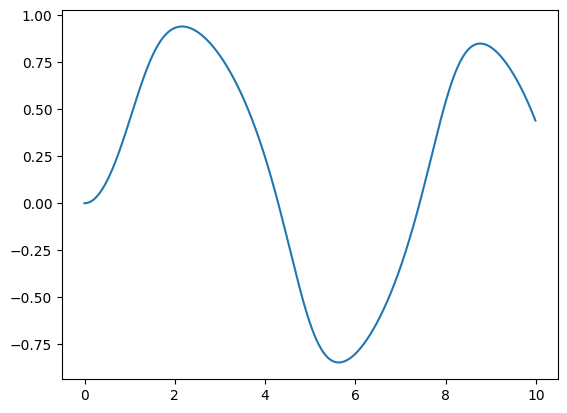

In [22]:
#Euler method:
import numpy as np
import matplotlib.pyplot as plt

#create a array com o tempo e aumentar o x de acordo com o passo "h" e
# A função acrescida com o tempo do array
def f(x,t):
    return -x**3 + np.sin(t)

def euler_method(a,b,N):
    h = (b-a)/N
    tpoints = np.arange(a,b,h)
    xpoints = []
    x = 0
    for t in (tpoints):
        xpoints.append(x)
        x += h*f(x,t)
    return xpoints,tpoints

xpoints,tpoints = euler_method(0,10,1000)

plt.plot(tpoints,xpoints)
plt.show()



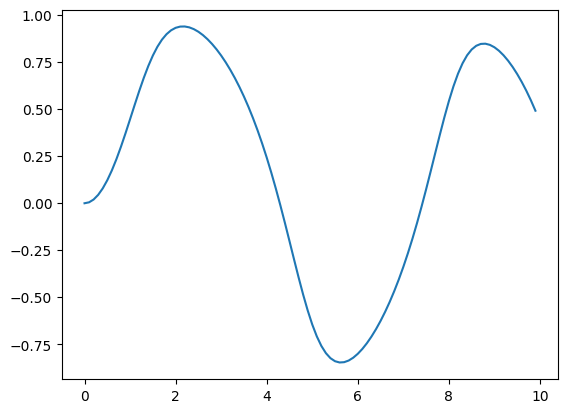

In [41]:
def runge_kutta2(a,b,N):
    h = (b-a)/N
    x = 0
    xpoints = []
    tpoints = np.arange(a,b,h)
    for t in tpoints:
        xpoints.append(x)
        k1 = h*f(x,t)
        k2 = h*f(x+0.5*k1,t+0.5*h)
        x += k2
    return xpoints,tpoints


xpoints,tpoints = runge_kutta2(0,10,100)

plt.plot(tpoints,xpoints)
plt.show()

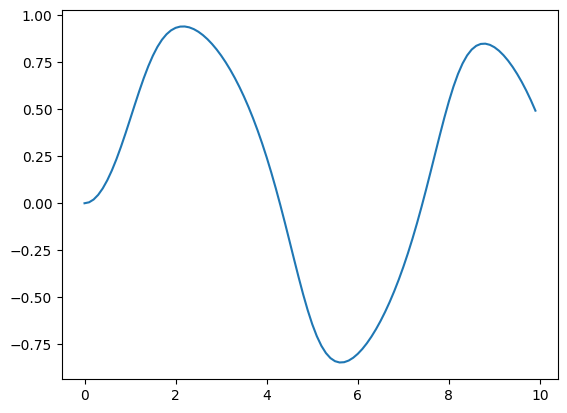

In [42]:
def runge_kutta4(a,b,N):
    h = (b-a)/N
    x = 0
    xpoints = []
    tpoints = np.arange(a,b,h)
    for t in tpoints:
        xpoints.append(x)
        k1 = h*f(x,t)
        k2 = h*f(x+0.5*k1,t+0.5*h)
        k3 = h*f(x+0.5*k2,t+0.5*h)
        k4 = h*f(x+k3,t+h)
        x += (k1+2*k2+2*k3+k4)/6
    
    return xpoints,tpoints

xpoints, tpoints = runge_kutta4(0,10,100)

plt.plot(tpoints,xpoints)
plt.show()


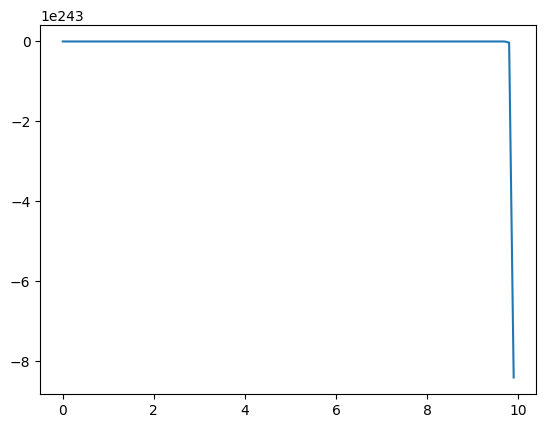

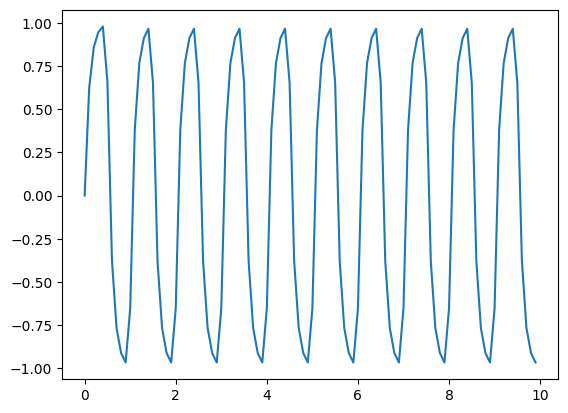

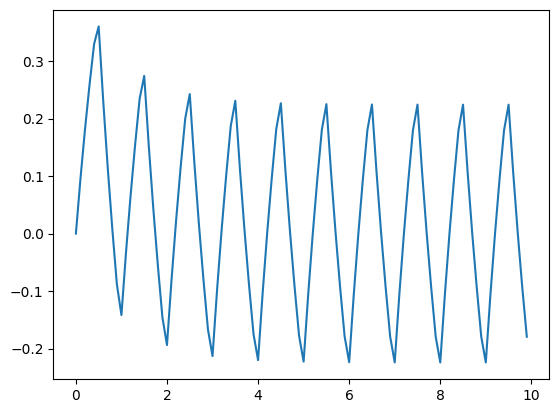

In [56]:
def f(x,t,RC):
    if int(2*t) % 2 == 0:
        return (1/RC)*(1-x)
    else: 
        return (1/RC)*(-1-x)
    
def runge_kutta4adaptado(a,b,N,RC):
    h = (b-a)/N
    x = 0 #condição inicial
    Vout = []
    tpoints = np.arange(a,b,h)
    for t in tpoints:
        Vout.append(x)
        k1 = h*f(x,t,RC)
        k2 = h*f(x+0.5*k1,t+0.5*h,RC)
        k3 = h*f(x+0.5*k2,t+0.5*h,RC)
        k4 = h*f(x+k3,t+h,RC)
        x += (k1+2*k2+2*k3+k4)/6

    return Vout,tpoints

RCarray = [0.01,0.1,1]
Valores_totais = []

for RC in RCarray:
    plt.plot(runge_kutta4adaptado(0,10,100,RC)[1],runge_kutta4adaptado(0,10,100,RC)[0])
    plt.show()


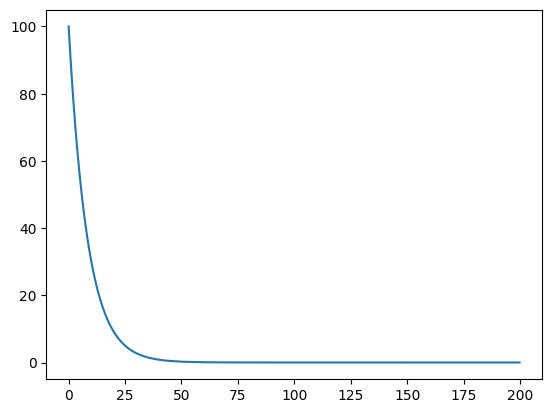

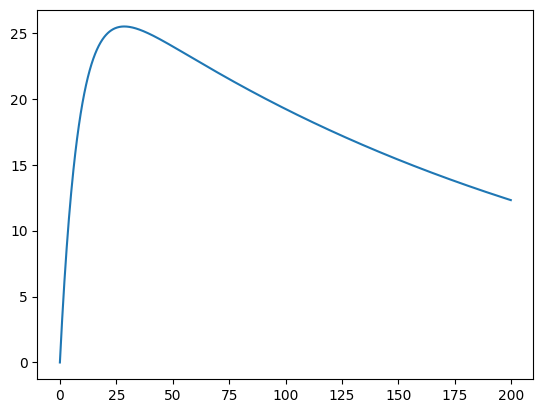

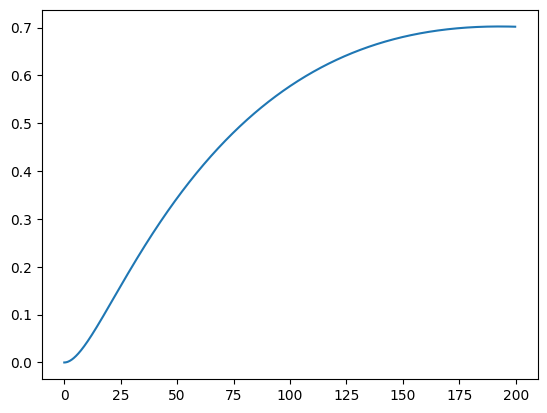

143
28.6
13.029524503744813


In [72]:
def lambdas(T):
    return np.log(2)/T
lambdaA = lambdas(0.25*24)
lambdaB = lambdas(80*24)
lambdaC = lambdas(12*24)
lambdaD = lambdas(7*24)
phi = 0.3
e = 0.2
A = 100
r = [A,0,0]

def f(r,t):
    B = r[0]
    Y = r[1]
    R = r[2]

    dB = -(phi*lambdaA +(1-phi)*lambdaA+lambdaD)*B + (1-e)*lambdaC*R
    dY = -(lambdaB + lambdaD)*Y + phi*lambdaA*B
    dR = -(lambdaD + lambdaC)*R + lambdaB*Y
    return np.array([dB,dY,dR],float)


def runge_kutta4mv(a,b,N,r):
    h = (b-a)/N
    tpoints = np.arange(a,b,h)
    Bpoints = []
    Ypoints = []
    Rpoints = []

    for t in tpoints:
        Bpoints.append(r[0])
        Ypoints.append(r[1])
        Rpoints.append(r[2])
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1,t+0.5*h)
        k3 = h*f(r+0.5*k2,t+0.5*h)
        k4 = h*f(r+k3,t+h)
        r += (k1+2*k2+2*k3+k4)/6

    return Bpoints,Ypoints,Rpoints,tpoints

Bpoints,Ypoints,Rpoints,tpoints = runge_kutta4mv(0,200,1000,r = [A,0,0])

plt.plot(tpoints,Bpoints)
plt.show()

plt.plot(tpoints,Ypoints)
plt.show()

plt.plot(tpoints,Rpoints)
plt.show()



print(np.argmax((Ypoints)))

print(tpoints[143])

print(Ypoints[-1]+Bpoints[-1]+Rpoints[-1])